In [1]:
import numpy as np
data=np.load('data.npy')
target=np.load('target.npy')


In [2]:
train_data=data[:1000]
train_target=target[:1000]

test_data=data[1000:]
test_target=target[1000:]


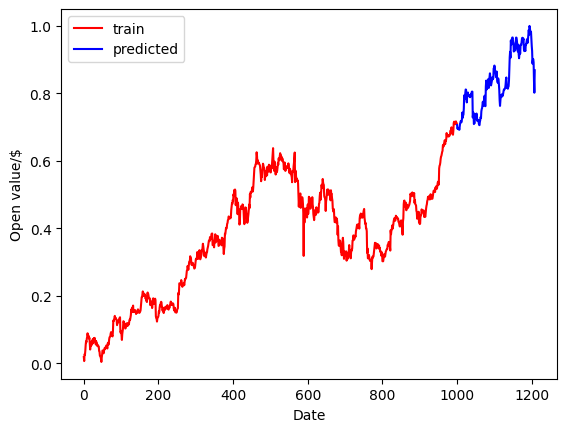

In [10]:
from matplotlib import pyplot as plt
test_x_range=np.arange(1000,len(data),1)

plt.plot(train_target,'r',label='train')
plt.plot(test_x_range,test_target,'b',label='test')

plt.xlabel('Date')
plt.ylabel('Open value/$')
plt.legend(['train','predicted'])
plt.show()

In [12]:
from keras.models import Sequential
from keras.layers import LSTM,Dense,Dropout

model=Sequential()

model.add(LSTM(units=96,return_sequences=True,input_shape=(data.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(units=96,return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=96,return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=96,return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(units=1,activation='linear'))

model.compile(optimizer='adam',loss='mean_squared_error')

In [32]:
history=model.fit(train_data,train_target,epochs=200,batch_size=32)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 3.7819e-04
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 3.8785e-04
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 3.4759e-04
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 3.9386e-04
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 3.7602e-04
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 3.8018e-04
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 3.2714e-04
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 3.3133e-04
Epoch 9/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 3.0761e-04
Epoch 10/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 3.1243e-04
Epoch 11/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 3.5411e-04
Epoch 12/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 3.7600e-04
Epoch 13/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 3.6964e-04
Epoch 14/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 3.6350e-04
E

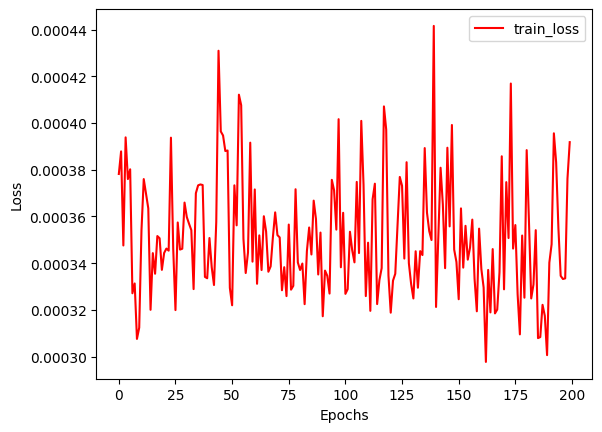

In [33]:
plt.plot(history.history['loss'],'r',label='train_loss')
#plt.plot(history.history['val_loss'],'g',label='val_loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [34]:
result=model.predict(test_data)
from sklearn.metrics import r2_score
r2=r2_score(test_target,result)
print('R2 score is :',r2)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
R2 score is : 0.8614038918926148


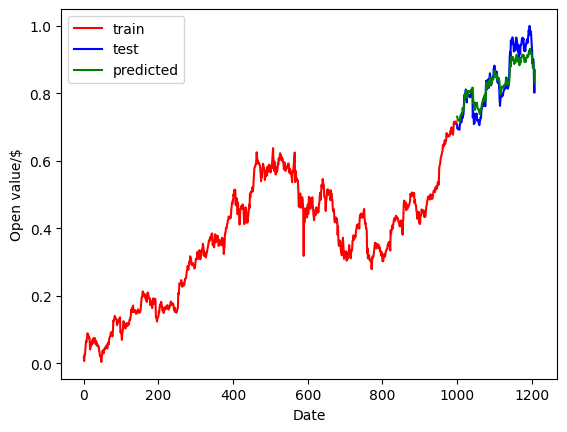

In [35]:
test_x_range=np.arange(1000,len(data),1)
plt.plot(train_target,'r',label='train')
plt.plot(test_x_range,test_target,'b',label='test')
plt.plot(test_x_range,result,'g',label='predicted')
plt.xlabel('Date')
plt.ylabel('Open value/$')
plt.legend()
plt.show()


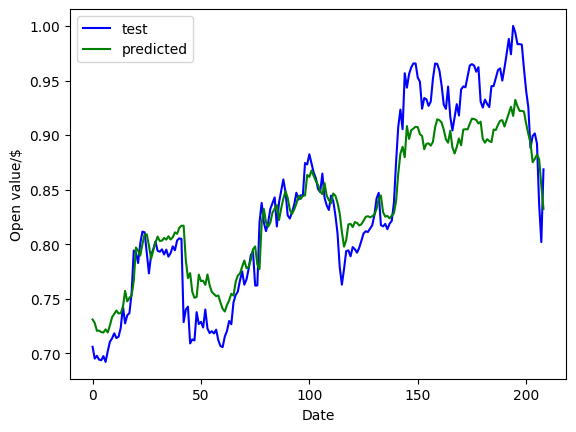

In [36]:
plt.plot(test_target,'b',label='test')
plt.plot(result,'g',label='predicted')
plt.xlabel('Date')
plt.ylabel('Open value/$')
plt.legend()
plt.show()